In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

#Check version
torch.__version__

'2.6.0+cu126'

In [3]:
#Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
!nvidia-smi

Tue Mar  4 02:19:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 571.96                 Driver Version: 571.96         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   63C    P8             11W /   64W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
#Create some data using linear regression formula (y = weight * x + bias)
weight = 0.7
bias = 0.3

#Create range values
start = 0
end = 1
step = 0.02

#Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [6]:
#Split the data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
print(len(X_train), len(X_test))

40 10


In [7]:
def plot_predictions(train_data = X_train, 
                     train_labels = y_train,
                     test_data = X_test, 
                     test_labels = y_test, 
                     predictions = None):
    """
    Plots training data, test data and compares predictions
    """ 

    plt.figure(figsize = (10, 7))

    #Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label = "Training data")

    #Plot test data in red
    plt.scatter(test_data, test_labels, c='g', s=4, label = "Testing data")

    #Are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label = "Predictions")

    #Show the legend (show our labels on the math plot)
    plt.legend(prop={"size" : 14})

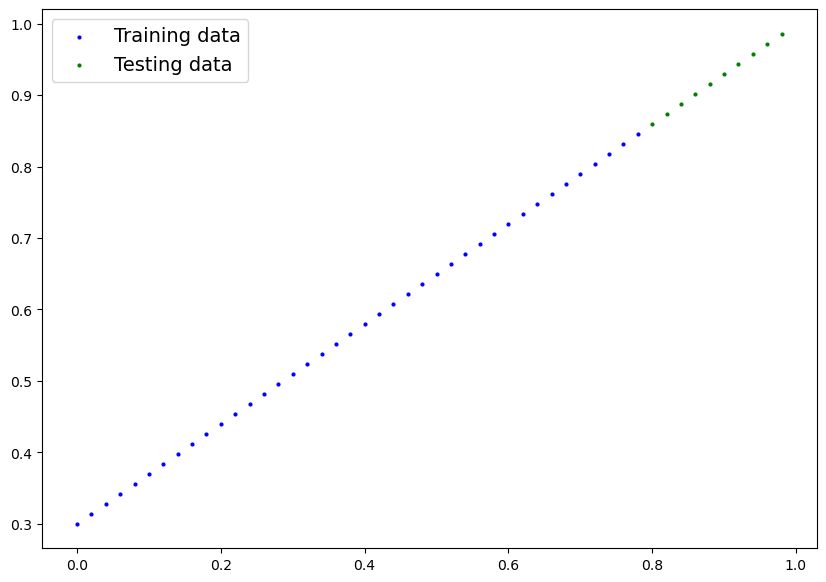

In [8]:
#Plot the data
plot_predictions(X_train, y_train, X_test, y_test)

### Building a PyTorch Linear Model

In [9]:
#Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        #Use nn.linear() to create model's parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

#Set manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [10]:
#Change the model's device
next(model_1.parameters()).device

device(type='cpu')

In [11]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### Training Model

In [12]:
loss_func = torch.nn.L1Loss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01)

In [13]:
torch.manual_seed(42)

epochs = 200

#Put data on the target device (cuda in this case)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    #1. Forward pass
    y_pred = model_1(X_train)

    #2. Calculate loss
    loss = loss_func(y_pred, y_train)

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Perform backpropagation
    loss.backward()

    #5. Optimizer step
    optimizer.step()

    # Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_func(test_pred, y_test)
    print(f"Epoch : {epoch} | Loss : {loss} | Test loss: {test_loss}")

Epoch : 0 | Loss : 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch : 1 | Loss : 0.5436570048332214 | Test loss: 0.560505211353302
Epoch : 2 | Loss : 0.5321359634399414 | Test loss: 0.5470342636108398
Epoch : 3 | Loss : 0.5206149816513062 | Test loss: 0.5335632562637329
Epoch : 4 | Loss : 0.5090939998626709 | Test loss: 0.5200923085212708
Epoch : 5 | Loss : 0.49757298827171326 | Test loss: 0.5066213011741638
Epoch : 6 | Loss : 0.4860520362854004 | Test loss: 0.4931503236293793
Epoch : 7 | Loss : 0.47453102469444275 | Test loss: 0.4796793460845947
Epoch : 8 | Loss : 0.4630100429058075 | Test loss: 0.4662083685398102
Epoch : 9 | Loss : 0.45148906111717224 | Test loss: 0.45273739099502563
Epoch : 10 | Loss : 0.439968079328537 | Test loss: 0.4392664134502411
Epoch : 11 | Loss : 0.42844706773757935 | Test loss: 0.42579540610313416
Epoch : 12 | Loss : 0.4169261157512665 | Test loss: 0.4123244285583496
Epoch : 13 | Loss : 0.4054051339626312 | Test loss: 0.39885345101356506
Epoch : 14 

In [14]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [20]:
model_1.eval()
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

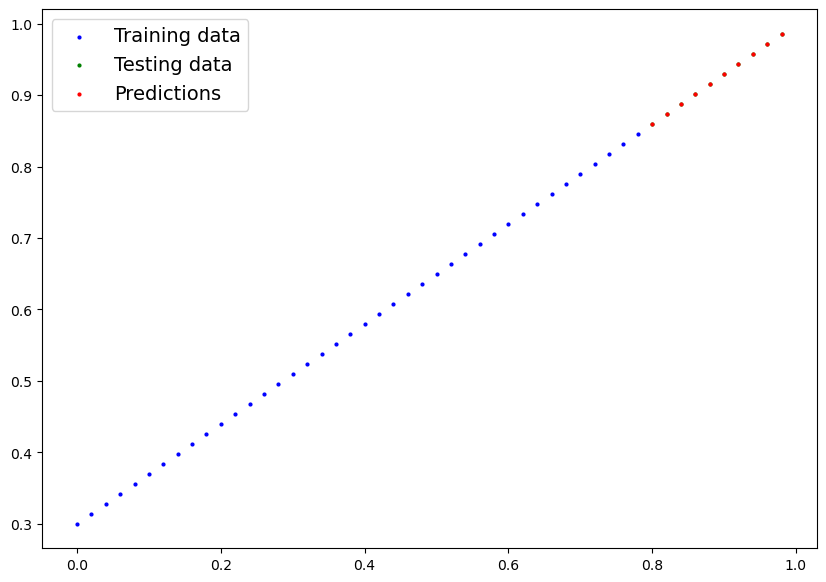

In [17]:
plot_predictions(predictions=y_preds.cpu())

In [18]:
#Load the training model
from pathlib import Path
model_path = Path("models")

model_name = "1.Rewrite_model.pth"
model_path = model_path / model_name

print("Saving model path...")
torch.save(obj = model_1.state_dict(), f = model_path)

Saving model path...


In [23]:
load_model = LinearRegressionModelV2()
load_model.load_state_dict(torch.load(model_path))

load_model.eval()
with torch.inference_mode():
    load_preds = model_1(X_test)

y_preds == load_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')